# Cardiovascular Disease Risk Prediction  
## Data Understanding and Preprocessing

The objective of this notebook is to analyze and preprocess the dataset before applying machine learning models. Proper preprocessing ensures that the data is clean, structured, and suitable for predictive modeling.

Steps:
- Load and inspect dataset
- Analyze structure and missing values
- Clean and preprocess data
- Convert categorical variables to numeric
- Prepare dataset for modeling

##Import Libraries

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

##Load Dataset

In [ ]:
df = pd.read_csv("CVD_cleaned.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 308,854 rows × 19 columns


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


##Dataset Overview

In [58]:
df.shape

(308854, 19)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

In [60]:
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


The dataset contains 308854 rows and 19 columns.  
We observe a mix of categorical and numerical variables.

## Missing Values Analysis

Before applying any preprocessing techniques, we verified whether the dataset contains missing values.

Handling missing data is an important step in data preprocessing because:
- Missing values can negatively affect model performance.
- Some algorithms cannot handle null values.
- Improper handling may introduce bias.

We checked for missing values using the `isnull().sum()` function.

In [61]:
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

### Interpretation

The output shows that all columns contain 0 missing values.

This indicates that:
- The dataset is complete.
- No imputation (mean/median/mode filling) is required.
- No rows or columns need to be removed due to missing data.

Therefore, we can proceed directly to the next preprocessing step (categorical encoding and feature transformation).

In [62]:
df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

In [63]:
#number of duplicated
df.duplicated().sum()

np.int64(80)

In [64]:
#removing duplicates
df_copy = df.copy()
df_copy.drop_duplicates(inplace=True)
df_copy.duplicated().sum()

np.int64(0)

## 🔢 6. Categorical Encoding

Machine learning models require **numerical inputs**. We convert each categorical feature using an appropriate strategy:

| Feature | Strategy | Reason |
|---------|----------|--------|
| `General_Health` | Ordinal map (0–4) | Ordered categories (Poor → Excellent) |
| `Binary columns` | Yes→1, No→0 | Boolean features |
| `Diabetes` | Grouped binary | Multiple diabetes types → positive class |
| `Sex` | Male→1, Female→0 | Binary nominal |
| `Age_Category` | Midpoint mapping | Preserves ordinal distance |
| `Checkup` | Time-based numeric | Reflects real-world elapsed time |


In [65]:
# --- General Health (ordinal) ---
health_map = {"Poor": 0, "Fair": 1, "Good": 2, "Very Good": 3, "Excellent": 4}
df_copy["General_Health"] = df_copy["General_Health"].map(health_map)

# --- Binary columns ---
binary_cols = [
    "Exercise", "Heart_Disease", "Skin_Cancer",
    "Other_Cancer", "Depression", "Arthritis", "Smoking_History"
]
for col in binary_cols:
    df_copy[col] = df_copy[col].str.strip().map({"Yes": 1, "No": 0})

# --- Diabetes (multi-category → binary) ---
df_copy["Diabetes"] = df_copy["Diabetes"].astype(str).str.strip().replace({
    "No": 0,
    "No, pre-diabetes or borderline diabetes": 0,
    "Yes": 1,
    "Yes, but female told only during pregnancy": 1
})

# --- Sex ---
df_copy["Sex"] = df_copy["Sex"].map({"Male": 1, "Female": 0})

# --- Age Category (midpoint) ---
age_map = {
    "18-24": 21, "25-29": 27, "30-34": 32, "35-39": 37,
    "40-44": 42, "45-49": 47, "50-54": 52, "55-59": 57,
    "60-64": 62, "65-69": 67, "70-74": 72, "75-79": 77, "80+": 85
}
df_copy["Age_Category"] = df_copy["Age_Category"].map(age_map)

# --- Checkup (time-based) ---
checkup_map = {
    "Within the past year":   1,
    "Within the past 2 years": 2,
    "Within the past 5 years": 3,
    "5 or more years ago":    4,
    "Never":                  5
}
df_copy["Checkup"] = df_copy["Checkup"].astype(str).str.strip().map(checkup_map)

print("Encoding complete. Data types after encoding:")
print(df_copy.dtypes)
df_copy.head()


Encoding complete. Data types after encoding:
General_Health                    int64
Checkup                           int64
Exercise                          int64
Heart_Disease                     int64
Skin_Cancer                       int64
Other_Cancer                      int64
Depression                        int64
Diabetes                          int64
Arthritis                         int64
Sex                               int64
Age_Category                      int64
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                   int64
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object


C:\Users\molka\AppData\Local\Temp\ipykernel_26532\2549220913.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy["Diabetes"] = df_copy["Diabetes"].astype(str).str.strip().replace({


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,2,0,0,0,0,0,0,1,0,72,150.0,32.66,14.54,1,0.0,30.0,16.0,12.0
1,3,1,0,1,0,0,0,1,0,0,72,165.0,77.11,28.29,0,0.0,30.0,0.0,4.0
2,3,1,1,0,0,0,0,1,0,0,62,163.0,88.45,33.47,0,4.0,12.0,3.0,16.0
3,0,1,1,1,0,0,0,1,0,1,77,180.0,93.44,28.73,0,0.0,30.0,30.0,8.0
4,2,1,0,0,0,0,0,0,0,1,85,191.0,88.45,24.37,1,0.0,8.0,4.0,0.0


## Outlier Detection and Treatment

Outliers were detected using the Interquartile Range (IQR) method.

The IQR is calculated as:

IQR = Q3 − Q1

where:
- Q1 represents the first quartile (25th percentile)
- Q3 represents the third quartile (75th percentile)

The acceptable range of values is defined as:

Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR

Values falling outside this range are considered outliers.

Instead of removing these observations, outlier values were replaced
with the median of the corresponding feature. The median was chosen
because it is less sensitive to extreme values and helps preserve the
overall distribution of the data.

This method was applied to the numerical variables:
Height_(cm), Weight_(kg), and BMI.

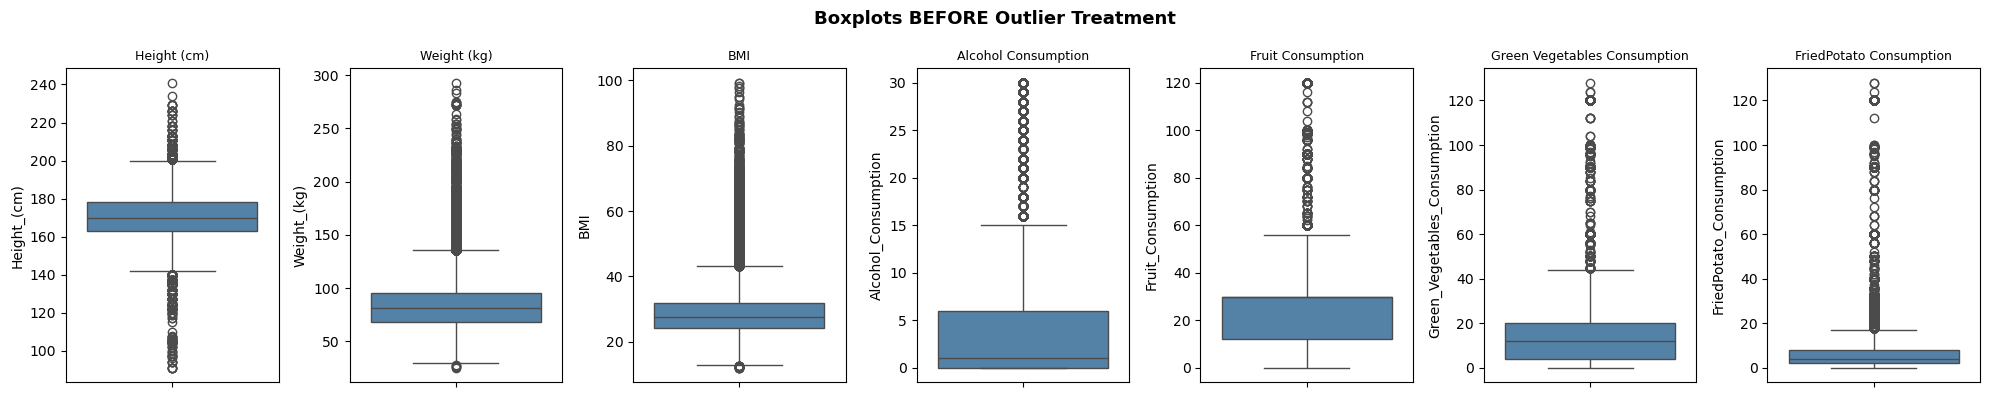

Outlier counts before treatment:
  Height_(cm): 1,055
  Weight_(kg): 7,326
  BMI: 9,530
  Alcohol_Consumption: 36,147
  Fruit_Consumption: 68,212
  Green_Vegetables_Consumption: 11,877
  FriedPotato_Consumption: 19,456


In [66]:
num_cols = [
    "Height_(cm)", "Weight_(kg)", "BMI",
    "Alcohol_Consumption", "Fruit_Consumption",
    "Green_Vegetables_Consumption", "FriedPotato_Consumption"
]

# --- Visualise before treatment ---
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_copy[col], ax=ax, color="steelblue")
    ax.set_title(col.replace("_", " "), fontsize=9)
fig.suptitle("Boxplots BEFORE Outlier Treatment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Count outliers ---
def count_outliers(col):
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    return ((col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)).sum()

print("Outlier counts before treatment:")
for col in num_cols:
    print(f"  {col}: {count_outliers(df_copy[col]):,}")


In [67]:
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return column[(column < lower) | (column > upper)]

for col in num_cols:
    outliers = detect_outliers_iqr(df_copy[col])
    print(f"{col}: {len(outliers)} outliers")

Height_(cm): 1055 outliers
Weight_(kg): 7326 outliers
BMI: 9530 outliers
Alcohol_Consumption: 36147 outliers
Fruit_Consumption: 68212 outliers
Green_Vegetables_Consumption: 11877 outliers
FriedPotato_Consumption: 19456 outliers


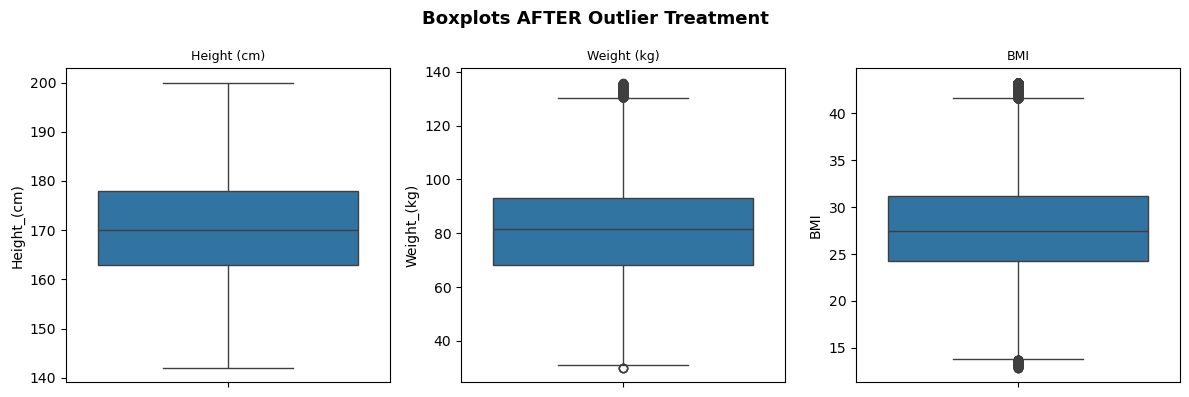

In [68]:
# --- Apply IQR capping with median replacement ---
cols_to_treat = ["Height_(cm)", "Weight_(kg)", "BMI"]

for col in cols_to_treat:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median_val = df_copy[col].median()
    df_copy[col] = np.where(
        (df_copy[col] < lower) | (df_copy[col] > upper),
        median_val, df_copy[col]
    )

# --- Visualise after treatment ---
fig, axes = plt.subplots(1, len(cols_to_treat), figsize=(12, 4))
for ax, col in zip(axes, cols_to_treat):
    sns.boxplot(y=df_copy[col], ax=ax)
    ax.set_title(col.replace("_", " "), fontsize=9)
fig.suptitle("Boxplots AFTER Outlier Treatment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Correlation Analysis

Before training the machine learning models, a correlation analysis is performed to explore the relationships between the different variables in the dataset.

The correlation matrix provides a numerical measure of the strength and direction of the linear relationship between pairs of features. Values close to:

- **+1** indicate a strong positive correlation.
- **-1** indicate a strong negative correlation.
- **0** indicate little or no linear relationship.

This analysis helps identify:
- Strong relationships between features.
- Potential multicollinearity issues.
- Variables that may contain redundant information.

Understanding these relationships is important for feature selection and model optimization.

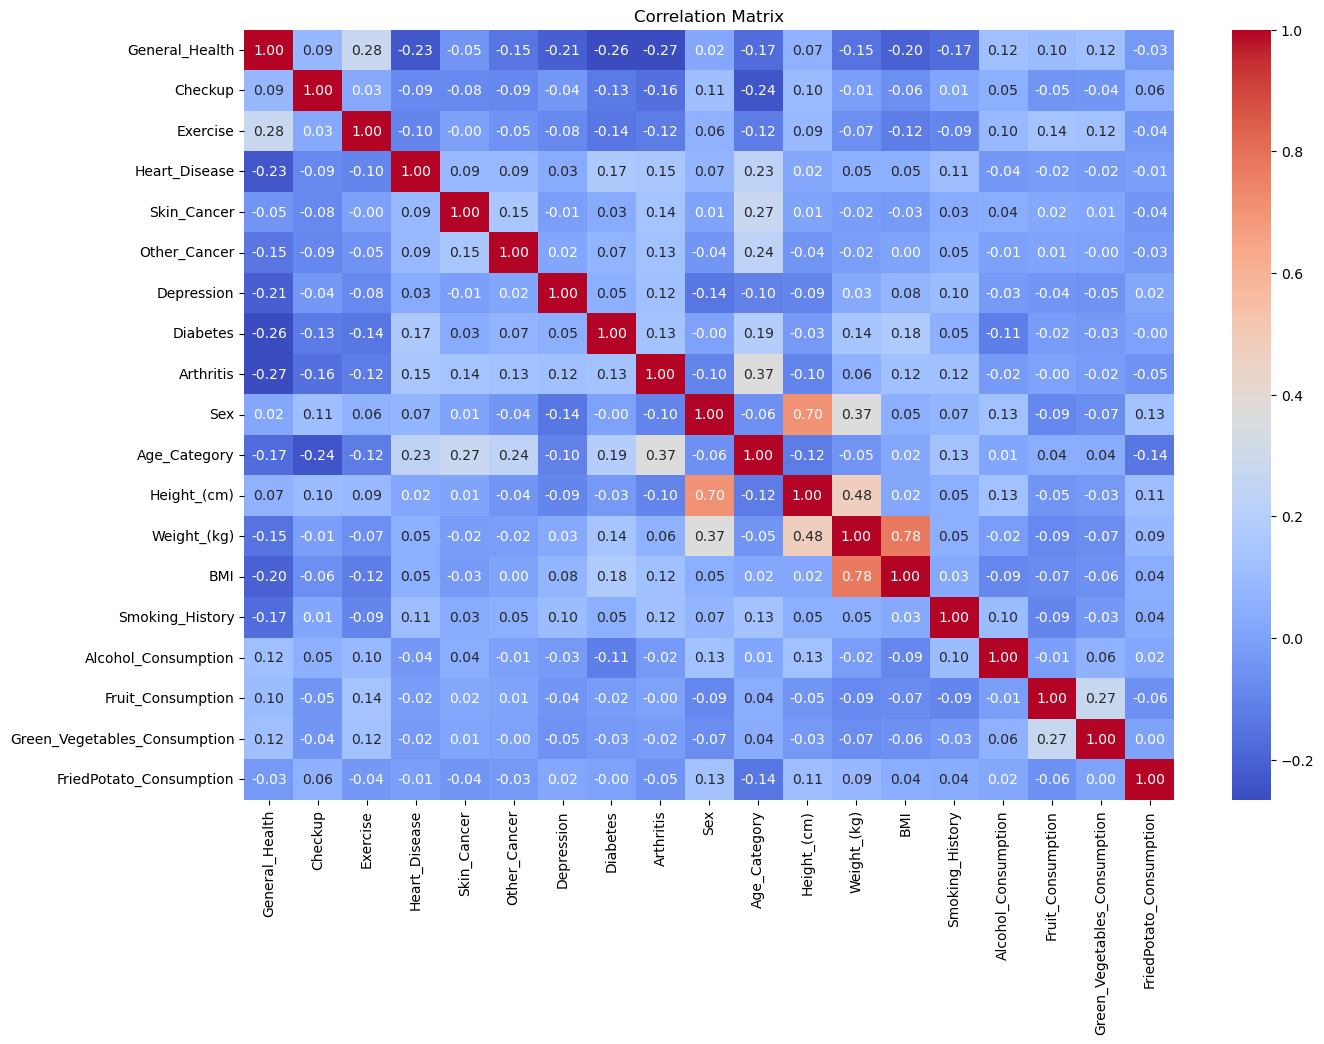

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_copy.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Correlation Between Features and Heart Disease

To better understand the factors associated with cardiovascular disease, the correlation between each feature and the target variable (**Heart_Disease**) is analyzed.

This analysis allows us to:

- Identify the variables most strongly associated with heart disease.
- Determine which features may have greater predictive power.
- Detect variables with very weak relationships that could potentially be removed during feature selection.

A higher absolute correlation value indicates a stronger relationship with the target variable, while values close to zero suggest a limited contribution to prediction.

In [70]:
target_corr = (
    df_copy.corr(numeric_only=True)["Heart_Disease"]
    .sort_values(ascending=False)
)

print(target_corr)

Heart_Disease                   1.000000
Age_Category                    0.230139
Diabetes                        0.172183
Arthritis                       0.153891
Smoking_History                 0.107757
Other_Cancer                    0.092369
Skin_Cancer                     0.090835
Sex                             0.072606
Weight_(kg)                     0.047975
BMI                             0.045773
Depression                      0.032494
Height_(cm)                     0.016597
FriedPotato_Consumption        -0.009249
Fruit_Consumption              -0.020045
Green_Vegetables_Consumption   -0.024027
Alcohol_Consumption            -0.036614
Checkup                        -0.085630
Exercise                       -0.096321
General_Health                 -0.232484
Name: Heart_Disease, dtype: float64


## Interpretation of Correlation Results

The correlation analysis reveals varying levels of association between the explanatory variables and the target variable.

Features with higher absolute correlation values are likely to have a greater influence on cardiovascular disease prediction. Conversely, features with correlations close to zero may contribute less information individually.

The correlation matrix also helps identify highly correlated features that may introduce redundancy into the dataset. These observations will be considered during the feature selection stage to improve model performance and reduce unnecessary complexity.

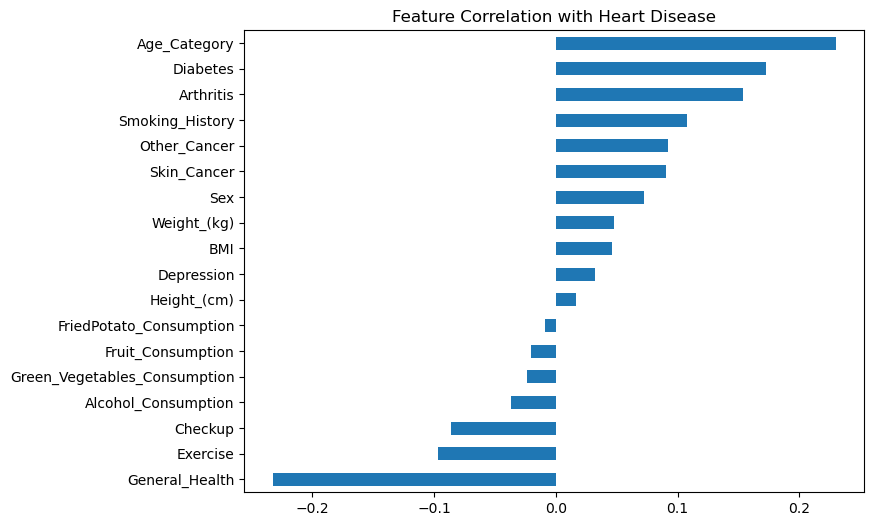

In [71]:
plt.figure(figsize=(8,6))

target_corr.drop("Heart_Disease").sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Heart Disease")
plt.show()

In [72]:
corr_threshold = 0.02

important_features = target_corr[
    abs(target_corr) > corr_threshold
].index

print(important_features)

Index(['Heart_Disease', 'Age_Category', 'Diabetes', 'Arthritis',
       'Smoking_History', 'Other_Cancer', 'Skin_Cancer', 'Sex', 'Weight_(kg)',
       'BMI', 'Depression', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'Alcohol_Consumption', 'Checkup',
       'Exercise', 'General_Health'],
      dtype='object')


In [73]:
df_reduced = df_copy[important_features]

# Class Imbalance Analysis & Handling

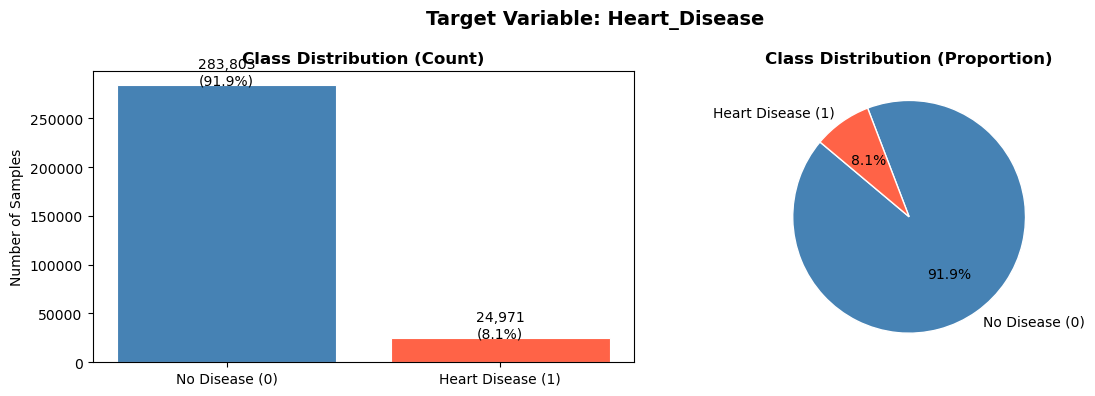

In [74]:
target_counts = df_reduced["Heart_Disease"].value_counts()
target_pct = df_reduced["Heart_Disease"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["No Disease (0)", "Heart Disease (1)"],
            target_counts.values,
            color=["steelblue", "tomato"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Distribution (Count)", fontweight="bold")
axes[0].set_ylabel("Number of Samples")
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 500, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=10)

# Pie chart
axes[1].pie(target_counts.values,
            labels=["No Disease (0)", "Heart Disease (1)"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=140, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Distribution (Proportion)", fontweight="bold")

plt.suptitle("Target Variable: Heart_Disease", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Train-Test Split

The dataset was split into training and testing sets using an 80/20 ratio.

Stratified sampling was applied to preserve the original class
distribution of the target variable `Heart_Disease` in both sets.

This ensures a fair evaluation of model performance.

In [75]:
from sklearn.model_selection import train_test_split

X = df_reduced.drop("Heart_Disease", axis=1)
y = df_reduced["Heart_Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Modeling Pipeline

A machine learning pipeline was implemented to ensure a consistent and fair evaluation process across different data splits and models.

The pipeline includes the following steps:

1. **Handling Class Imbalance (SMOTE)**  
   SMOTE (Synthetic Minority Oversampling Technique) is applied only to the training data to balance the distribution of the target variable.  
   This helps the model learn patterns from the minority class (Heart_Disease = 1).

2. **Feature Scaling**  
   Standardization is applied using StandardScaler to normalize feature values.  
   This ensures that all variables contribute equally to the model and improves performance.

3. **Model Training**  
   Machine learning models are trained on the processed training data.

4. **Evaluation**  
   The trained models are evaluated on the test data using multiple metrics.

In [76]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

def run_pipeline(X_train, X_test, y_train, y_test, split_name, model, model_name):

    # 1. SMOTE on train only
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # 2. Scaling: fit on train, transform both
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_test_scaled = scaler.transform(X_test)

    # 3. Train the model
    model.fit(X_train_res, y_train_res)

    # 4. Predict
    y_pred = model.predict(X_test_scaled)

    # 5. Metrics
    acc    = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)

    print(f"\n{'='*55}")
    print(f"  Model: {model_name} | Split: {split_name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred))

    return {
        "Model"        : model_name,
        "Split"        : split_name,
        "Accuracy"     : round(acc, 4),
        "Recall"       : round(recall, 4),
        "F1-Score"     : round(f1, 4),
        "trained_model": model,
        "X_test_scaled": X_test_scaled,
        "y_test"       : y_test
    }

In [77]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
X = df_copy.drop("Heart_Disease", axis=1)
y = df_copy["Heart_Disease"]

models = {
    "Logistic Regression" : LogisticRegression(C=0.01, solver='liblinear', random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"         : GaussianNB(),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
}

splits = {
    "80/20": train_test_split(X, y, test_size=0.2, random_state=42, stratify=y),
    "70/30": train_test_split(X, y, test_size=0.3, random_state=42, stratify=y),
    "90/10": train_test_split(X, y, test_size=0.1, random_state=42, stratify=y),
}

results = []

for split_name, (X_train, X_test, y_train, y_test) in splits.items():
    for model_name, model in models.items():
        results.append(
            run_pipeline(X_train, X_test, y_train, y_test, split_name, model, model_name)
        )


  Model: Logistic Regression | Split: 80/20
              precision    recall  f1-score   support

           0       0.95      0.81      0.88     56761
           1       0.20      0.53      0.29      4994

    accuracy                           0.79     61755
   macro avg       0.58      0.67      0.58     61755
weighted avg       0.89      0.79      0.83     61755


  Model: Decision Tree | Split: 80/20
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     56761
           1       0.18      0.29      0.22      4994

    accuracy                           0.84     61755
   macro avg       0.56      0.59      0.57     61755
weighted avg       0.87      0.84      0.85     61755


  Model: Random Forest | Split: 80/20
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     56761
           1       0.27      0.23      0.25      4994

    accuracy                           0.89     61755
   ma

## Model Evaluation

The models were evaluated using multiple metrics including accuracy,
precision, recall, and F1-score.

Accuracy alone is not sufficient due to class imbalance. Therefore,
special attention was given to recall and F1-score for the minority
class (Heart_Disease = 1).

- Recall measures the model’s ability to correctly identify patients
  with heart disease.
- Precision measures how many predicted positive cases are actually correct.
- F1-score provides a balance between precision and recall.

These metrics provide a more reliable evaluation of model performance
in a medical prediction context.

In [78]:
import pandas as pd

# extract only the columns meant for display
display_cols = ["Model", "Split", "Accuracy", "Recall", "F1-Score"]
df_results = pd.DataFrame([{k: r[k] for k in display_cols} for r in results])
df_results = df_results.sort_values("Recall", ascending=False).reset_index(drop=True)

print("\n Comparison — All Models & Splits:\n")
print(df_results.to_string(index=False))

best_idx = df_results["Recall"].idxmax()
best = df_results.iloc[best_idx]
print(f"\n Best combination by Recall: {best['Model']} with {best['Split']} split")
print(f"   → Recall   : {best['Recall']}")
print(f"   → F1-Score : {best['F1-Score']}")
print(f"   → Accuracy : {best['Accuracy']}")


 Comparison — All Models & Splits:

              Model Split  Accuracy  Recall  F1-Score
        Naive Bayes 90/10    0.6996  0.6103    0.2473
        Naive Bayes 80/20    0.6958  0.5999    0.2418
        Naive Bayes 70/30    0.6986  0.5934    0.2415
Logistic Regression 90/10    0.7925  0.5326    0.2933
Logistic Regression 80/20    0.7894  0.5300    0.2893
Logistic Regression 70/30    0.7899  0.5245    0.2876
  Gradient Boosting 90/10    0.8747  0.3244    0.2951
  Gradient Boosting 80/20    0.8736  0.3146    0.2870
  Gradient Boosting 70/30    0.8726  0.3093    0.2820
      Decision Tree 90/10    0.8377  0.3028    0.2318
      Decision Tree 80/20    0.8354  0.2948    0.2246
      Decision Tree 70/30    0.8354  0.2942    0.2243
      Random Forest 80/20    0.8866  0.2313    0.2480
      Random Forest 90/10    0.8892  0.2311    0.2522
      Random Forest 70/30    0.8861  0.2261    0.2431

 Best combination by Recall: Naive Bayes with 90/10 split
   → Recall   : 0.6103
   → F1-Score : 0

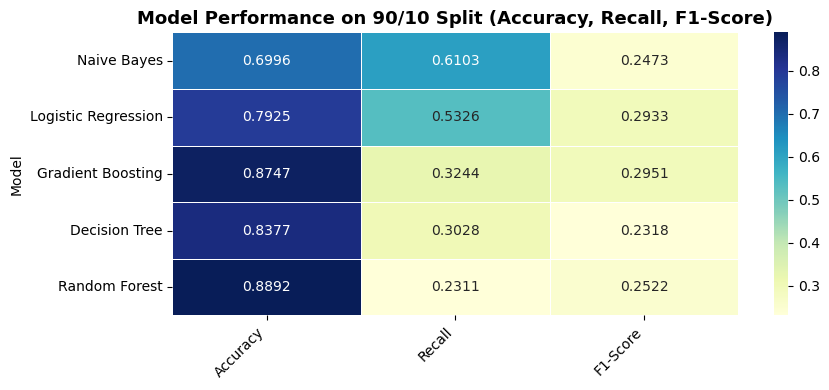

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap comparison (90/10 split only) ────────────────────────────
df_90 = df_results[df_results["Split"] == "90/10"].copy()
df_90 = df_90.set_index("Model")[["Accuracy", "Recall", "F1-Score"]]

plt.figure(figsize=(9, 4))
sns.heatmap(df_90, annot=True, cmap="YlGnBu", fmt=".4f", linewidths=.5)
plt.title("Model Performance on 90/10 Split (Accuracy, Recall, F1-Score)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Confusion matrices for all models (90/10 split)

## Confusion Matrices

### How to read a Confusion Matrix

```
                  Predicted 0    Predicted 1
Actual 0 (No CVD)     TN             FP
Actual 1 (CVD)        FN             TP
```

- **TN** (True Negative): correctly identified healthy patients  
- **TP** (True Positive): correctly identified CVD patients  ← we want this high  
- **FN** (False Negative): CVD patients labelled as healthy  ← **most dangerous error**  
- **FP** (False Positive): healthy patients labelled as CVD  ← less dangerous  


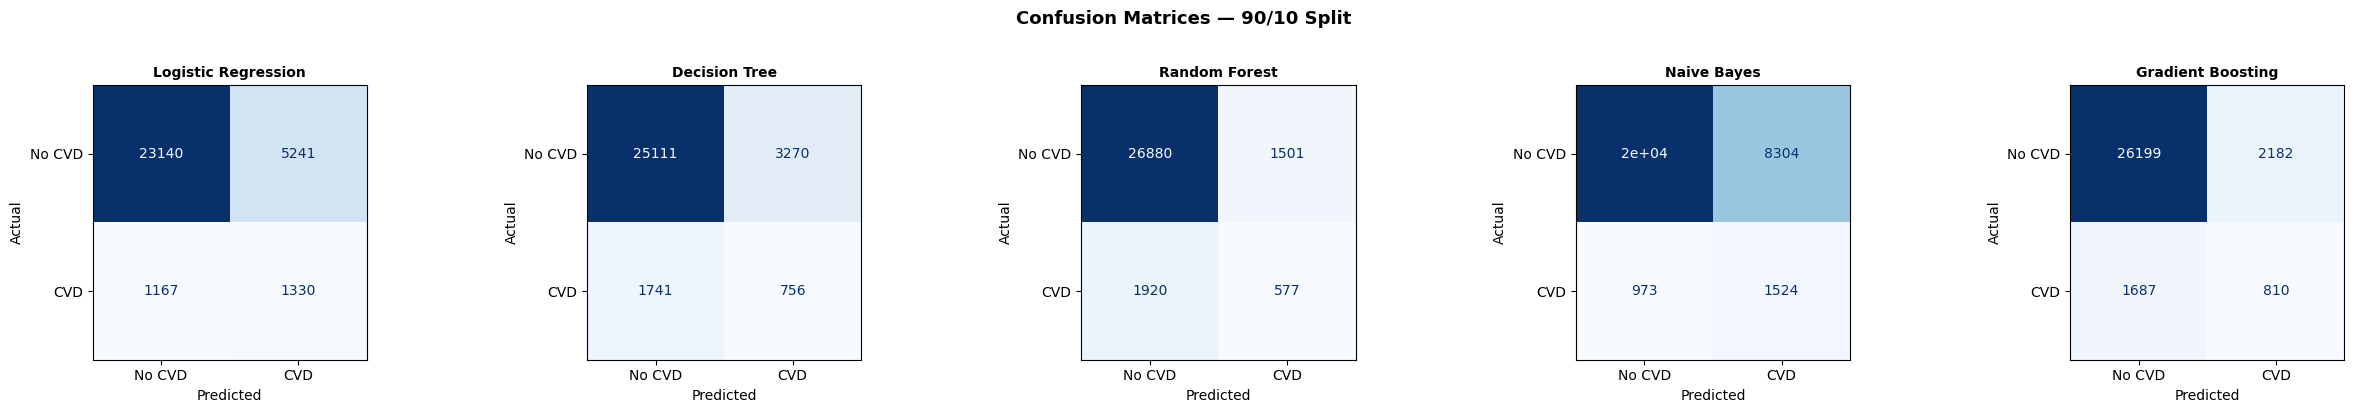

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Filter results for the 90/10 split
results_90 = [r for r in results if r["Split"] == "90/10"]

n = len(results_90)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

for i, res in enumerate(results_90):
    # Predict y_pred using the trained model and scaled test data
    y_pred = res["trained_model"].predict(res["X_test_scaled"])
    cm = confusion_matrix(res["y_test"], y_pred)

    # Ensure axes is iterable even for a single subplot
    ax = axes[i] if n > 1 else axes

    disp = ConfusionMatrixDisplay(cm, display_labels=["No CVD", "CVD"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(res["Model"], fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — 90/10 Split", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## ROC Curves & AUC Scores

### What is the ROC Curve?

The **Receiver Operating Characteristic (ROC)** curve plots:
- **X-axis**: False Positive Rate (FPR) = FP / (FP + TN)
- **Y-axis**: True Positive Rate / Recall (TPR) = TP / (TP + FN)

### What is AUC?

- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random classifier (diagonal line)
- **AUC > 0.8** → Good model; **AUC > 0.9** → Excellent

> The ROC curve is threshold-independent — it evaluates the model's ability to **rank** positive cases higher than negative ones, regardless of the chosen decision threshold.


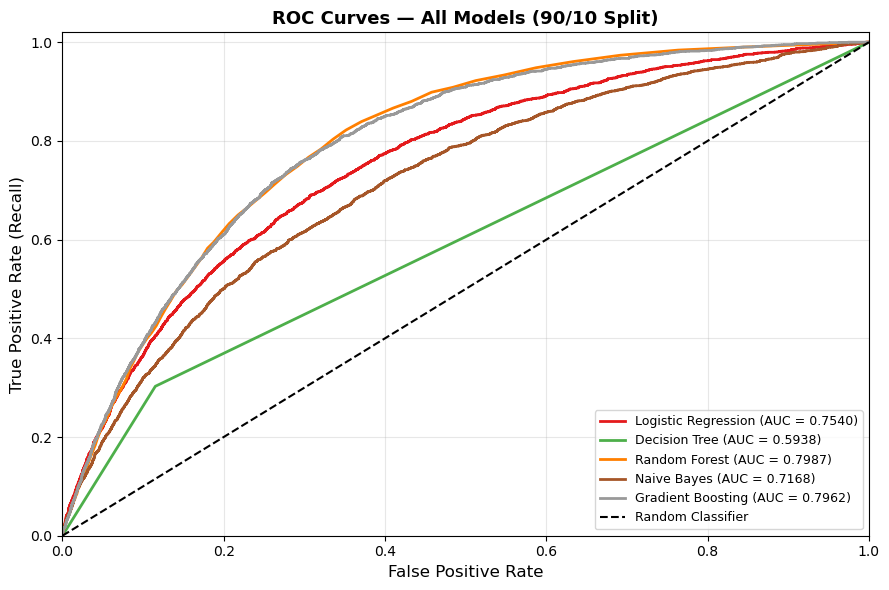


AUC Scores (90/10 Split):
----------------------------------------
  Logistic Regression      : AUC = 0.7540
  Decision Tree            : AUC = 0.5938
  Random Forest            : AUC = 0.7987
  Naive Bayes              : AUC = 0.7168
  Gradient Boosting        : AUC = 0.7962


In [81]:
from sklearn.metrics import roc_curve, auc

# Filter results for the 90/10 split
results_90 = [r for r in results if r["Split"] == "90/10"]

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.Set1(np.linspace(0, 1, len(results_90)))

for res, color in zip(results_90, colors):
    # Calculate y_proba for the current model
    y_proba = res["trained_model"].predict_proba(res["X_test_scaled"])[:, 1]
    fpr, tpr, _ = roc_curve(res["y_test"], y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{res['Model']} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves — All Models (90/10 Split)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Print AUC table ───
print("\nAUC Scores (90/10 Split):")
print("-" * 40)
for res in results_90:
    # Calculate y_proba for the current model
    y_proba = res["trained_model"].predict_proba(res["X_test_scaled"])[:, 1]
    fpr, tpr, _ = roc_curve(res["y_test"], y_proba)
    roc_auc = auc(fpr, tpr)
    print(f"  {res['Model']:25s}: AUC = {roc_auc:.4f}")

## Cross-Validation

Cross-validation is used to evaluate model performance more reliably by splitting the data into multiple parts.

### K-Fold vs Stratified K-Fold

| Method | Description | When to use |
|--------|------------|------------|
| K-Fold | Splits data into K equal parts | Balanced datasets |
| Stratified K-Fold | Keeps same class distribution in each fold | Imbalanced datasets |

### Why Stratified K-Fold?

Our dataset is imbalanced (~91% class 0, ~9% class 1).  
Using normal K-Fold may create folds with very few positive samples, leading to unreliable results.

Stratified K-Fold ensures each fold reflects the original distribution, making evaluation more accurate.


Logistic Regression
K-Fold     : 0.1083 ± 0.0095
Strat-KFold: 0.1089 ± 0.0181
Decision Tree
K-Fold     : 0.2271 ± 0.0125
Strat-KFold: 0.2198 ± 0.0084
Random Forest
K-Fold     : 0.0886 ± 0.0077
Strat-KFold: 0.0793 ± 0.0082
Naive Bayes
K-Fold     : 0.3244 ± 0.0105
Strat-KFold: 0.3229 ± 0.0090
Gradient Boosting
K-Fold     : 0.1238 ± 0.0111
Strat-KFold: 0.1121 ± 0.0085


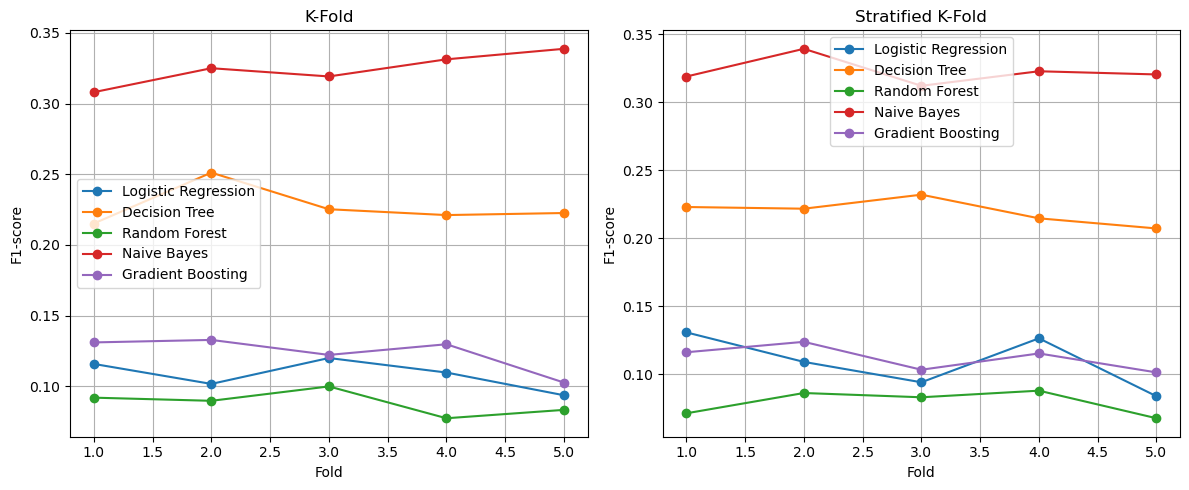

,Model,KF Mean F1,KF Std,SKF Mean F1,SKF Std
0,Logistic Regression,0.1083,0.0095,0.1089,0.0181
1,Decision Tree,0.2271,0.0125,0.2198,0.0084
2,Random Forest,0.0886,0.0077,0.0793,0.0082
3,Naive Bayes,0.3244,0.0105,0.3229,0.0090
4,Gradient Boosting,0.1238,0.0111,0.1121,0.0085


In [82]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── Sample data (for speed) ──────────────────────────────────────────
np.random.seed(42)
sample_size = min(50000, len(X))
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)

X_cv = X.iloc[sample_idx].reset_index(drop=True)
y_cv = y.iloc[sample_idx].reset_index(drop=True)

# ─── Models (with proper pipelines) ───────────────────────────────────
cv_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.01, solver='liblinear', random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),

    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            random_state=42
        ))
    ])
}

# ─── CV strategies ────────────────────────────────────────────────────
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

# ─── Run CV ───────────────────────────────────────────────────────────
for model_name, model in cv_models.items():

    kf_scores = cross_val_score(model, X_cv, y_cv,
                               cv=kf, scoring="f1", n_jobs=-1)

    skf_scores = cross_val_score(model, X_cv, y_cv,
                                cv=skf, scoring="f1", n_jobs=-1)

    cv_results.append({
        "Model": model_name,
        "KF Mean F1": round(kf_scores.mean(), 4),
        "KF Std": round(kf_scores.std(), 4),
        "SKF Mean F1": round(skf_scores.mean(), 4),
        "SKF Std": round(skf_scores.std(), 4),
        "KF Scores": kf_scores,
        "SKF Scores": skf_scores
    })

    print(f"{'='*50}")
    print(model_name)
    print(f"K-Fold     : {kf_scores.mean():.4f} ± {kf_scores.std():.4f}")
    print(f"Strat-KFold: {skf_scores.mean():.4f} ± {skf_scores.std():.4f}")

# ─── Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, key, title in zip(axes,
                          ["KF Scores", "SKF Scores"],
                          ["K-Fold", "Stratified K-Fold"]):

    for res in cv_results:
        ax.plot(range(1, 6), res[key], marker="o", label=res["Model"])

    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel("F1-score")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

# ─── Summary table ────────────────────────────────────────────────────
cv_df = pd.DataFrame([{k: v for k, v in r.items() if "Scores" not in k}
                      for r in cv_results])

cv_df

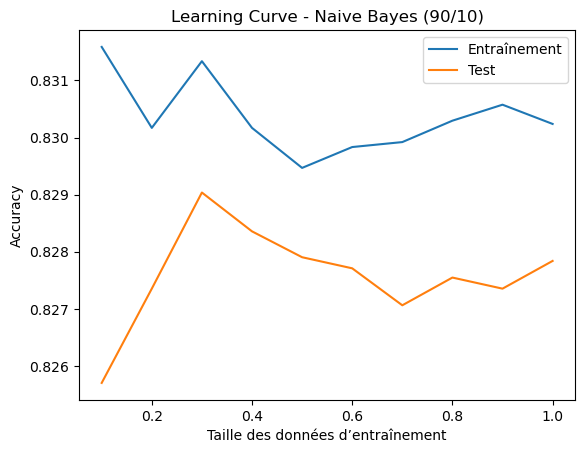

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Split 90/10
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

train_scores = []
test_scores = []

# Create progressive training sizes (like "fake iterations")
sizes = np.linspace(0.1, 1.0, 10)

for s in sizes:
    # Take a subset of training data
    subset_size = int(len(X_train) * s)
    X_train_subset = X_train[:subset_size]
    y_train_subset = y_train[:subset_size]

    # Train Naive Bayes
    model = GaussianNB()
    model.fit(X_train_subset, y_train_subset)

    # Predictions
    y_train_pred = model.predict(X_train_subset)
    y_test_pred = model.predict(X_test)

    # Scores
    train_scores.append(accuracy_score(y_train_subset, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

# Plot
plt.figure()
plt.plot(sizes, train_scores, label='Entraînement')
plt.plot(sizes, test_scores, label='Test')
plt.xlabel('Taille des données d’entraînement')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Naive Bayes (90/10)')
plt.legend()
plt.show()

## Threshold Tuning

Instead of using the default classification threshold (0.5),
a custom threshold was applied to adjust the balance between
precision and recall.

Lowering the threshold increases recall, allowing the model
to detect more cases of heart disease, at the cost of more
false positives.

This approach is particularly useful in medical applications
where detecting positive cases is more important than avoiding
false alarms.

In [84]:
# Find the best Naive Bayes result by Recall
lr_results = [r for r in results if r["Model"] == "Naive Bayes"]
best_lr_result = max(lr_results, key=lambda r: r["Recall"])

# Extract what we saved
best_lr_model  = best_lr_result["trained_model"]
X_test_scaled  = best_lr_result["X_test_scaled"]
y_test_best    = best_lr_result["y_test"]

print(f"Applying threshold tuning on: Naive Bayes | {best_lr_result['Split']} split\n")

# Get predicted probabilities for the positive class (Heart Disease = 1)
y_probs = best_lr_model.predict_proba(X_test_scaled)[:, 1]

# Try multiple thresholds and compare
thresholds = [0.5, 0.4, 0.3, 0.2]

for threshold in thresholds:
    y_pred_custom = (y_probs >= threshold).astype(int)
    recall = recall_score(y_test_best, y_pred_custom)
    f1     = f1_score(y_test_best, y_pred_custom)
    acc    = accuracy_score(y_test_best, y_pred_custom)
    print(f"Threshold {threshold} → Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {acc:.4f}")

Applying threshold tuning on: Naive Bayes | 90/10 split

Threshold 0.5 → Recall: 0.6103 | F1: 0.2473 | Accuracy: 0.6996
Threshold 0.4 → Recall: 0.6428 | F1: 0.2387 | Accuracy: 0.6685
Threshold 0.3 → Recall: 0.6844 | F1: 0.2341 | Accuracy: 0.6379
Threshold 0.2 → Recall: 0.7337 | F1: 0.2270 | Accuracy: 0.5958
